# C1 Practical 24: from tide gauges to global mean sea level

*Lectures 23 and 24. Michaelmas 2026.*


> Open this notebook in Google Colab with the button on the course page, then choose *File > Save a copy in Drive*
> so that your changes are kept. Questions marked **[paper]** are answered on paper. Cells marked *run* need
> only be run; some have settings you can change, which appear as sliders and menus in Colab. A changed setting
> takes effect only when the cell is run again.


**Constants.** 360 Gt of ice is one millimetre of global mean sea level; Earth radius 6371 km.

> **Solutions version.** Cells beginning *Answer* are the worked solutions and demonstrator notes.

In [ ]:
#@title Run this cell first. It fetches the data files and a small helper module.
import os, sys, pathlib, urllib.request
BASE = "https://raw.githubusercontent.com/da380/c1-practicals/main/"
here = pathlib.Path("../data") if pathlib.Path("../data/c1prac.py").exists() else pathlib.Path("data")
here.mkdir(exist_ok=True)
if not pathlib.Path("../data/c1prac.py").exists():          # in Colab: always fetch the current helper module
    urllib.request.urlretrieve(BASE + "data/c1prac.py", here / "c1prac.py")
    for m in [k for k in sys.modules if k == "c1prac"]:
        del sys.modules[m]
sys.path.insert(0, str(here))
try:
    import pyslfp
except ImportError:                       # in Colab: about a minute
    import subprocess; subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyslfp"], check=True); import pyslfp
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pyslfp import subplots, plot_points
from c1prac import get, load_json, global_map, regional_map, weighted_least_squares
print("Ready.")

## 1. Two warm-ups from Lecture 23  [paper]

**(a) The budget as a difference of large numbers.** Greenland receives about 700 Gt yr$^{-1}$ of snow, loses about
250 Gt yr$^{-1}$ as melt-water runoff, and discharges about 500 Gt yr$^{-1}$ of ice across its grounding lines. Suppose
each of these is known to ten per cent. What is the rate of mass change and its uncertainty, in Gt yr$^{-1}$ and in mm
yr$^{-1}$ of sea level? Comment on what this means for the input-output method.

**(b) Resolution.** A spherical harmonic of degree $l$ has a half-wavelength of about $20\,000/l$ km. What degree is
needed to separate Greenland from Ellesmere Island, 500 km away across Nares Strait? What does truncation at degree 60
mean for an outlet glacier ten kilometres wide? Why are the degree-one coefficients absent from the satellite gravity
field, and what does their absence do to the Antarctic mass balance?

**Cell A** takes the load of one year of Greenland ice loss (250 Gt, distributed like the present ice sheet), expands it in
spherical harmonics, truncates the expansion at several degrees, and integrates the result over Greenland.

In [ ]:
#@title Cell A: the same load seen at increasing spherical harmonic degree
tr = np.load(get("greenland_truncation.npz")); lon, lat, mask = tr["lon"], tr["lat"], tr["mask"]
fig, axes = subplots(2, 2, ccrs.PlateCarree(), figsize=(13, 8.5))
for ax, L in zip(axes.flat, [20, 40, 60, 96]):
    regional_map(tr[f"ewt_L{L}"] * 1000, lon, lat, lon_range=(-80, 0), lat_range=(55, 85), ax=ax, vmin=-150, vmax=150, cmap="RdBu",
                 title=f"truncated at degree {L}", label="mm of water", contours=(0.0,) if L <= 60 else ())
    ax.contour(lon, lat, mask, levels=[0.5], colors="g", linewidths=1, transform=ccrs.PlateCarree())
plt.show()
for L, gt in zip(tr["degrees"], tr["gt_over_greenland"]):
    print(f"degree {int(L):3d}: integral over Greenland (green outline) = {gt:6.1f} Gt of the 250 Gt removed")

**(c)** Describe what happens to the load as the truncation degree is reduced, and explain why the integral over
Greenland is not equal to 250 Gt at low degree. This is *leakage*. What assumption is needed to correct for it?

**Answer.** **(a)** $dM/dt = 700 - 250 - 500 = -50$ Gt yr$^{-1}$, with uncertainty $\sqrt{70^2 + 25^2 + 50^2} \approx 90$ Gt yr$^{-1}$:
that is $-0.14 \pm 0.25$ mm yr$^{-1}$. The imbalance is a small difference of large terms, and its uncertainty exceeds
the signal even though each term is known to ten per cent. The input-output method is therefore poor at the absolute
number, but because it separates the terms it is the best method for saying *why* the mass is changing and the only one
that reaches back before the satellite era.

**(b)** $l \approx 20\,000/500 = 40$. At degree 60 the half-wavelength is about 330 km, so a ten-kilometre glacier is
invisible: only the sum of the loss over a few hundred kilometres of coast is recovered (a degree of about 2000 would
be needed). The degree-one terms describe a shift of the centre of mass relative to the solid Earth; the satellites
orbit the centre of mass, so this shift is invisible to them and must be supplied from a model of how the melt water
is distributed. Left out, it biases the Antarctic balance by tens of gigatonnes per year, a third of the signal,
because Antarctic melt moves mass from the southern to the northern hemisphere.

**(c)** As the degree is reduced the sharp edge of the ice sheet is smeared over a few hundred kilometres: mass appears
to be lost from the surrounding ocean and from Ellesmere Island, and the amplitude over the ice falls. The integral over
Greenland recovers 274 Gt at degree 20, 253 at degree 40 and 250 at degree 60 for 250 Gt removed
(at low degree the smearing carries mass both out of the mask and, from the concentrated coastal loss, into its
interior, so the integral can err either way). To correct it one must assume where the mass actually is, for example
that all of it lies on the ice sheet and that the ocean part is the smeared image of it, which is the assumption a
leakage correction or a mascon prior encodes.

## 2. The weighted mean and its bias  [paper]

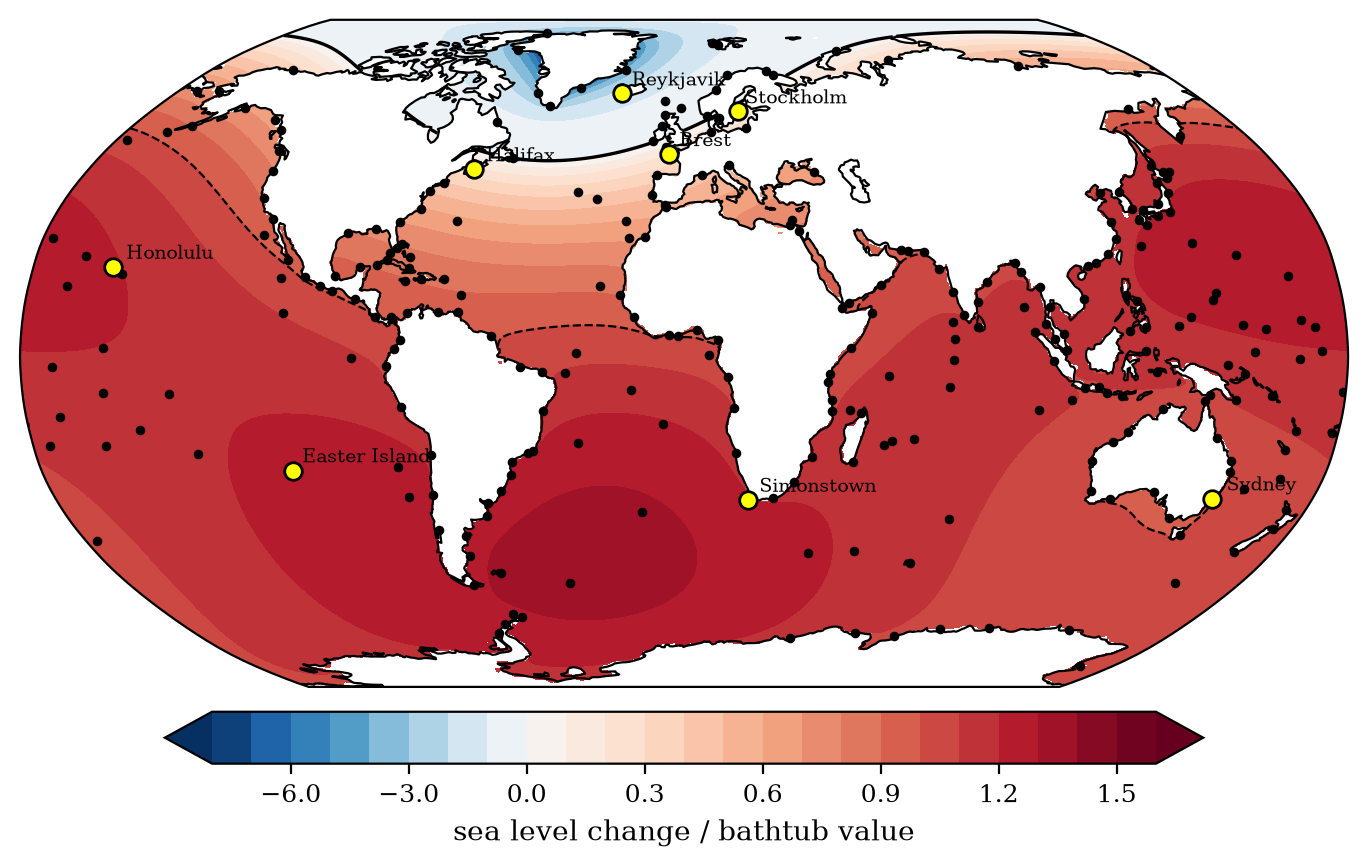<p style="font-size:90%;color:#444"><em>The Greenland fingerprint, normalised by its barystatic value, with the GLOSS tide gauge network.</em></p>

Four tide gauges record the change in relative sea level over one year. The readings have been corrected for glacial
isostatic adjustment, ocean dynamics and local land motion, with the uncertainties of the corrections included in the
standard deviations. Within a simple model the change at gauge $i$ is a weighted sum of the barystatic contributions
$\Delta B_j$ of the three ice sheets,
$$ \Delta SL_i = a_{iG}\,\Delta B_G + a_{iW}\,\Delta B_W + a_{iE}\,\Delta B_E + \epsilon_i , $$
where the coefficients are the values of the three fingerprints at the gauge (each normalised to unit ocean mean)
and $\epsilon_i$ is a random error of standard deviation $\sigma_i$.

| Gauge | lat | lon | $a_{iG}$ (Greenland) | $a_{iW}$ (West Antarctica) | $a_{iE}$ (East Antarctica) | reading / mm | $\sigma$ / mm |
|---|---|---|---|---|---|---|---|
| Stockholm | 59.3 | 18.1 | 0.076 | 1.013 | 1.072 | 0.449 | 0.02 |
| Halifax | 44.7 | -63.6 | 0.223 | 1.230 | 1.066 | 0.634 | 0.01 |
| Honolulu | 21.3 | -157.9 | 1.206 | 1.296 | 1.213 | 1.335 | 0.01 |
| Simonstown | -34.2 | 18.4 | 1.209 | 1.119 | 0.913 | 1.315 | 0.03 |

**(a)** Describe the main features of the Greenland fingerprint above and explain the physical processes that give it
its form, including rotation.

**(b)** Estimate the global mean sea level rise by forming the weighted mean of the four readings with weights
$w_i = 1/\sigma_i^2$.

**(c)** Show that the weighted mean is, apart from the random errors, a combination
$b_G\,\Delta B_G + b_W\,\Delta B_W + b_E\,\Delta B_E$ of the ice-sheet contributions, derive the expression for $b_j$, and
evaluate the three coefficients.

**(d)** The true global mean rise is $\Delta B_G + \Delta B_W + \Delta B_E$. Is your estimate in (b) biased, in which
direction, and why? Which network of gauges would count Greenland correctly?

**(e)** Solve the three-parameter model by weighted least squares instead (the normal equations; three unknowns, four
data). You need not complete the arithmetic by hand, but write down the equations and say why this estimate of the
total is unbiased when the mean is not, and what it assumes.

**Answer.** **(a)** Sea level falls steeply within about 2000 km of Greenland, by up to seven times the mean rise near the coast;
the zero contour passes close to the British Isles; far from Greenland sea level rises by up to a third more than the
mean, with the largest values in the southern hemisphere. The near-field fall combines the elastic rebound of the sea
floor (about 60 per cent) and the loss of the ice sheet's gravitational attraction (40 per cent); the far-field excess is
the water displaced from the near field, and its structure includes the four-quadrant pattern of the rotational
feedback, about ten per cent of the mean.

**(b)** Weights: Stockholm 2500, Halifax 10000, Honolulu 10000, Simonstown 1111 mm$^{-2}$, sum 23611. Weighted mean
$= 0.943$ mm.

**(c)** Substituting the model into the mean,
$\overline{\Delta SL} = \sum_i w_i \sum_j a_{ij}\Delta B_j / \sum_i w_i + \text{errors} = \sum_j b_j\,\Delta B_j + \text{errors}$
with $b_j = \sum_i w_i a_{ij} / \sum_i w_i$. The values are $b_G = 0.670$, $b_W = 1.230$, $b_E = 1.122$.

**(d)** Yes. If the coefficients were all one the mean would estimate the true total; they are not, so the estimate
counts Greenland at only 67 per cent and the Antarctic ice sheets at 123 and 112 per cent. (The readings
were in fact generated from $\Delta B_G = 0.7$, $\Delta B_W = 0.3$, $\Delta B_E = 0.1$ mm, a true
total of 1.10 mm; the expected value of the weighted mean is 0.95 mm, a bias of -14 per cent, and
the noise is small beside it.) The bias arises because the sea level change is not a constant plus noise but has a
systematic spatial pattern set by where the mass came from, and this network, with its two precise northern gauges near
Greenland's zero contour, sits where the Greenland signal is below its mean. A network that counts Greenland correctly
would need its weight distributed so that $\sum w_i a_{iG} / \sum w_i = 1$, for example more weight in the far field of
Greenland (the southern oceans) and less in the North Atlantic; no real network does this for all three sources at
once.

**(e)** Minimise $\sum_i w_i(\Delta SL_i - \sum_j a_{ij}\Delta B_j)^2$; setting the derivatives with respect to each $\Delta B_j$
to zero gives the normal equations $\sum_i w_i a_{ik}\Delta SL_i = \sum_j (\sum_i w_i a_{ik}a_{ij})\,\Delta B_j$ for $k = G, W, E$:
three linear equations in three unknowns. Their solution is $\Delta B = (0.69, 0.44, -0.06)$ mm with a total of
1.08 mm, against the true 1.10 mm. The estimate is unbiased because the model is linear in the unknowns and, if the
fingerprints are correct, substituting the true model back reproduces the true amplitudes whatever they are; the
weighted mean, by contrast, assumes a pattern (a constant) that the physics does not produce. The least-squares estimate
assumes that the patterns are known exactly and that the three sources are the only ones, and with four gauges the
Antarctic pair is poorly separated (standard errors 0.09 and 0.10 mm, strongly anti-correlated).

**Cell B.** The same experiment with all 290 gauges of the GLOSS network. Set the true contributions and the noise;
the cell generates readings, forms the weighted mean and the least-squares fit, and compares both with the truth.
Try changing the mix of sources at fixed total, and try restricting the network to the northern hemisphere.

In [ ]:
#@title Cell B: weighted mean versus least squares over the GLOSS network
greenland_mm = 0.7  #@param {type:"slider", min:0, max:2, step:0.1}
west_antarctic_mm = 0.3  #@param {type:"slider", min:0, max:2, step:0.1}
east_antarctic_mm = 0.1  #@param {type:"slider", min:0, max:2, step:0.1}
noise_mm = 0.3  #@param {type:"slider", min:0.05, max:2, step:0.05}
network = "all gauges"  #@param ["all gauges", "northern hemisphere only", "southern hemisphere only"]
import csv
rows = list(csv.DictReader(open(get("gloss_fingerprints.csv"))))
lat = np.array([float(r["lat"]) for r in rows]); lon = np.array([float(r["lon"]) for r in rows])
A = np.array([[float(r["a_greenland"]), float(r["a_west_antarctic"]), float(r["a_east_antarctic"])] for r in rows])
keep = {"all gauges": lat > -90, "northern hemisphere only": lat > 0, "southern hemisphere only": lat < 0}[network]
A, lat, lon = A[keep], lat[keep], lon[keep]
truth = np.array([greenland_mm, west_antarctic_mm, east_antarctic_mm])
rng = np.random.default_rng(1)
sigma = np.full(len(A), noise_mm)
d = A @ truth + rng.normal(0, noise_mm, len(A))
wmean = d.mean()
b = A.mean(axis=0)
m, cov, res = weighted_least_squares(A, d, sigma)
err = np.sqrt(np.diag(cov))
print(f"{len(A)} gauges. True contributions {truth} mm, true total {truth.sum():.2f} mm")
print(f"mean of the readings: {wmean:.2f} mm   (its expected value is b . truth with b = {np.round(b, 2)}, giving {b @ truth:.2f} mm)")
print(f"least squares: Greenland {m[0]:.2f} +/- {err[0]:.2f}, West Antarctica {m[1]:.2f} +/- {err[1]:.2f}, East Antarctica {m[2]:.2f} +/- {err[2]:.2f}; total {m.sum():.2f} +/- {np.sqrt(np.ones(3) @ cov @ np.ones(3)):.2f} mm")
corr = cov / np.outer(err, err)
print(f"correlation between the two Antarctic estimates: {corr[1, 2]:+.2f}")
fig, ax = subplots(1, 1, ccrs.Robinson(), figsize=(11.7, 5.85))
plot_points(list(zip(lat, lon)), data=d, ax=ax, s=18, cmap="RdBu_r", vmin=truth.sum() - 1.5, vmax=truth.sum() + 1.5, gridlines=False,
            colorbar=True, colorbar_kwargs={"label": "reading / mm", "shrink": 0.6})
ax.set_title("synthetic readings at the gauges"); plt.show()

## 3. Meltwater pulse 1A  [run]

Between about 14.7 and 14.2 ka global mean sea level rose by some 15 to 20 metres in a few centuries, the fastest rise in
the record. The sources have been argued over since Clark et al. (2002) first used fingerprints on three sites
(Barbados, Sunda Shelf, Tahiti). Lin et al. (2021, *Nature Communications*) added three more (two on the Great Barrier
Reef and the isolation basins of north-west Scotland) and inverted for three sources.

Here the geometry of the melt comes from the ICE-7G reconstruction: the change in ice thickness between 14.5 and 14.0 ka,
split into North America (including Greenland), Eurasia (Scandinavia and the Barents Sea, excluding the small British
ice sheet) and Antarctica. Each pattern has been normalised to one metre of barystatic rise and its elastic
fingerprint computed on the Earth of 14.5 ka, with its own shorelines, so the values at a site are the metres of local
rise per metre of global rise from that source. The local rises are the medians and standard deviations of the Lin et
al. reconstructions for a 500-year pulse.

| Site | lat | lon | local rise / m | $\sigma$ / m | $a$ (N. America) | $a$ (Eurasia) | $a$ (Antarctica) |
|---|---|---|---|---|---|---|---|
| Tahiti | -17.5 | -149.5 | 21.4 | 3.6 | 1.24 | 1.04 | 1.15 |
| Barbados | 13.1 | -59.5 | 15.6 | 1.7 | 0.82 | 1.01 | 1.21 |
| Sunda Shelf | 4.0 | 107.0 | 15.5 | 9.7 | 1.04 | 0.97 | 1.08 |
| Hydrographer's Passage | -19.7 | 150.3 | 19.9 | 5.7 | 1.06 | 1.01 | 1.19 |
| Noggin Pass | -17.1 | 146.6 | 19.2 | 6.6 | 1.04 | 1.01 | 1.18 |
| NW Scotland | 57.4 | -5.8 | 8.5 | 3.6 | 0.74 | -0.64 | 1.13 |

**Cell C** maps the three fingerprints on the 14.5 ka Earth.

In [ ]:
#@title Cell C: the three fingerprints at 14.5 ka
mw = np.load(get("mwp1a_fingerprints.npz")); lon, lat, ocean = mw["lon"], mw["lat"], mw["ocean"]
sites = {r["name"]: (r["lat"], r["lon"]) for r in load_json("mwp1a_sites.json")["sites"]}
fig, axes = subplots(1, 3, ccrs.Robinson(), figsize=(18.2, 5.07))
for k, (ax, key) in enumerate(zip(axes.flat, ["north_america", "eurasia", "antarctica"])):
    global_map(mw[key + "_sl"], lon, lat, ax=ax, vmin=-8, vmax=1.6, center=0, ocean=ocean, contours=(0.0, 1.0), sites=sites if k == 0 else None,
               title=key.replace("_", " "), label="/ bathtub value")
plt.show()

**Cell D. Fit by hand.** Set the metres of global mean rise from each source and compare the predicted local rise
at the six sites with the observations. Find a combination that fits all six, then see how much you can change it
while still fitting. Note which sites discriminate between sources and which only fix the total.

In [ ]:
#@title Cell D: turn the knobs
north_america_m = 12.0  #@param {type:"slider", min:0, max:25, step:0.5}
eurasia_m = 4.0  #@param {type:"slider", min:0, max:12, step:0.5}
antarctica_m = 1.0  #@param {type:"slider", min:0, max:15, step:0.5}
S = load_json("mwp1a_sites.json")["sites"]
names = [r["name"] for r in S]; A = np.array([r["a_ours"] for r in S]); d = np.array([r["median_m"] for r in S]); s = np.array([r["sigma_m"] for r in S])
m = np.array([north_america_m, eurasia_m, antarctica_m]); pred = A @ m
chi2 = np.sum(((d - pred) / s) ** 2)
fig, ax = plt.subplots(figsize=(10.4, 5.2))
x = np.arange(len(names)); ax.errorbar(x, d, yerr=s, fmt="ko", capsize=4, label="observed (Lin et al. 2021)")
ax.bar(x, pred, color="C0", alpha=0.6, label="predicted"); ax.axhline(m.sum(), color="C3", ls="--", label=f"global mean {m.sum():.1f} m")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=25, ha="right"); ax.set_ylabel("sea level rise during MWP1A / m"); ax.legend(frameon=False); plt.show()
print(f"global mean rise {m.sum():.1f} m;  chi-squared = {chi2:.1f} for 6 data (a good fit has chi-squared of about 3 to 6)")
for n, p, dd, ss in zip(names, pred, d, s):
    print(f"  {n:<24s} predicted {p:5.1f}  observed {dd:5.1f} +/- {ss:4.1f}")

**Cell E. Inversion.** The same problem solved by weighted least squares, with the choice of which sites to use.
Compare the six-site solution with the three sites available to Clark et al. (2002), and look at what happens to
the Antarctic estimate when Scotland is removed. The right-hand panel shows the misfit as a function of the North
American and Antarctic contributions, with the Eurasian contribution adjusted to its best value at each point.

In [ ]:
#@title Cell E: least-squares inversion for the three sources
use_Tahiti = True  #@param {type:"boolean"}
use_Barbados = True  #@param {type:"boolean"}
use_Sunda_Shelf = True  #@param {type:"boolean"}
use_Hydrographers_Passage = True  #@param {type:"boolean"}
use_Noggin_Pass = True  #@param {type:"boolean"}
use_NW_Scotland = True  #@param {type:"boolean"}
S = load_json("mwp1a_sites.json")["sites"]
flags = [use_Tahiti, use_Barbados, use_Sunda_Shelf, use_Hydrographers_Passage, use_Noggin_Pass, use_NW_Scotland]
keep = [k for k, f in enumerate(flags) if f]
names = [S[k]["name"] for k in keep]; A = np.array([S[k]["a_ours"] for k in keep]); d = np.array([S[k]["median_m"] for k in keep]); s = np.array([S[k]["sigma_m"] for k in keep])
m, cov, res = weighted_least_squares(A, d, s); err = np.sqrt(np.diag(cov)); corr = cov / np.outer(err, err)
print("sites used:", ", ".join(names))
for lab, mi, ei in zip(["North America", "Eurasia", "Antarctica"], m, err):
    print(f"  {lab:<14s} {mi:6.1f} +/- {ei:4.1f} m")
print(f"  total          {m.sum():6.1f} +/- {np.sqrt(np.ones(3) @ cov @ np.ones(3)):4.1f} m;   chi-squared {np.sum((res / s) ** 2):.1f} for {len(d)} data")
print("correlation matrix (NA, EU, AA):"); print(np.round(corr, 2))
print("Lin et al. (2021), six sites with a GIA model and non-negativity: North America 12.0 (5.6-15.4), Scandinavia 4.6 (3.2-6.4), Antarctica 1.3 (0-5.9), total 17.9 (15.7-20.2) m")
# misfit surface over (North America, Antarctica) with Eurasia optimised
na = np.linspace(0, 25, 126); aa = np.linspace(0, 15, 76); chi = np.zeros((aa.size, na.size))
w = 1 / s ** 2
for i, y in enumerate(aa):
    for j, x in enumerate(na):
        r = d - A[:, 0] * x - A[:, 2] * y
        e = np.sum(w * A[:, 1] * r) / np.sum(w * A[:, 1] ** 2)
        e = max(e, 0.0)
        chi[i, j] = np.sum(w * (r - A[:, 1] * e) ** 2)
fig, ax = plt.subplots(figsize=(8.45, 5.85))
cs = ax.contourf(na, aa, chi - chi.min(), levels=[0, 1, 2.3, 4, 6.2, 9, 12, 20, 50, 200], cmap="viridis_r", extend="max")
fig.colorbar(cs, label="increase in chi-squared above the minimum")
ax.plot(m[0], m[2], "r*", ms=12, label="least squares"); ax.plot(12.0, 1.3, "wo", label="Lin et al. 2021")
ax.set_xlabel("North America / m"); ax.set_ylabel("Antarctica / m"); ax.legend(frameon=False); ax.set_title("misfit with Eurasia at its best value")
plt.show()

**Questions [paper].**

**(a)** With all six sites, what are the three contributions and the total, and how do they compare with the published
solution? Why are they not identical (name at least two reasons)?

**(b)** Which sites fix the total and which discriminate between sources? Explain using the coefficients in the table:
what is special about Barbados and about Scotland?

**(c)** Using only Tahiti, Barbados and the Sunda Shelf, describe the solution and its uncertainties. Why could Clark
et al. not decide between a North American and an Antarctic source with these data, and what does the misfit surface
show about the trade-off?

**(d)** The fingerprints used here are elastic. The pulse lasted about five hundred years. Using Practical 22, say why
this is a concern and what Lin et al. did about it.

**(e)** In one paragraph, contrast this inversion with the weighted mean of question 2: what does each estimate, what
does each assume, and what would go wrong in each if a source were missing from the model?

**Answer.** **(a)** Six sites: North America 13.8 ± 8.3 m, Eurasia 3.6 ± 2.5 m, Antarctica 0.5 ± 6.1 m,
total 18.0 m. Lin et al. give 12.0, 4.7 and 1.3 m with a total of
17.9 m; the totals agree and the ranking of the sources is the same. Differences arise because our fingerprints
use the ICE-7G melt geometry on an elastic Earth while theirs come from several ice models on a viscoelastic GIA model
(with viscous corrections applied to the data); because they impose non-negativity and sample the full, skewed
uncertainty distributions of the site data rather than a Gaussian; and because the Scottish site is represented here by a
single point on a strongly varying part of the Eurasian fingerprint (our Eurasian coefficient there is -0.64
against their -0.74).

**(b)** Tahiti, the Sunda Shelf and the two Great Barrier Reef sites have coefficients near one for all three sources,
so each measures roughly the global mean and none can say where the water came from; they fix the total. Barbados
sees North American melt at only 0.82 of the mean, because it lies within the near-field depression of the
Laurentide fingerprint, but Antarctic melt at 1.21; its low observed rise therefore points to North
America. Scotland sees Eurasian melt *negatively* (-0.64): it lies inside the zero contour of the
Scandinavian fingerprint, where sea level falls as the ice is lost, and North American melt at 0.74. Its low rise,
about half the global mean, can only be produced by a large Eurasian contribution and rules out a large Antarctic one,
which would raise Scottish sea level by more than the global mean.

**(c)** Three sites: North America 46.2 ± 112.0 m, Eurasia -188.3 ± 651.5 m, Antarctica 138.7 ± 468.1 m. The
uncertainties are enormous and the estimates strongly correlated: with three data and three unknowns the total is
fixed by Tahiti and Sunda, and Barbados alone must separate the sources, which it can only do to the extent that its
coefficients differ. The misfit surface shows a long valley running from a North American solution to an Antarctic one
with little change in misfit, and Sunda's large uncertainty widens it. Clark et al. argued for Antarctica on the basis of
Barbados; the later data, particularly Scotland, closed the valley. (Cell E also shows that removing Scotland alone lets
the Antarctic estimate wander over many metres.)

**(d)** The Maxwell time of ordinary mantle is a few hundred years, so over a five-hundred-year pulse the mantle beneath
the melting ice sheets relaxes appreciably: the near-field fall grows with time as the viscous rebound adds to the
elastic one, and the far-field values change by a few per cent. Treating the fingerprint as elastic over-simplifies the
near and intermediate field, exactly where the discriminating sites are. Lin et al. computed the viscous part with a GIA
model ensemble and subtracted it from each site's record before fitting, noting that for the centennial timescale the
correction is not very sensitive to the choice of viscosity.

**(e)** The weighted mean estimates a single number, the global mean, and assumes that every gauge sees that number
plus noise; the pattern imposed by the physics then appears as a bias that cannot be removed by adding gauges. The
inversion estimates the amplitudes of assumed patterns, and the global mean as their sum; it is unbiased if the patterns
are right and the sources complete. If a source is missing from the model, the mean is biased by that source's pattern
in the usual way, while the inversion attributes the missing source's signal to the patterns it has, which can
misassign it entirely: an unmodelled ocean dynamic change or an omitted glacier source would be read as ice-sheet melt.
The remedy in the modern reconstructions is to include more patterns and, ultimately, to invert for the ice thickness
change itself with a prior, as in Lecture 24.

## 4. GIA corrections  [paper]

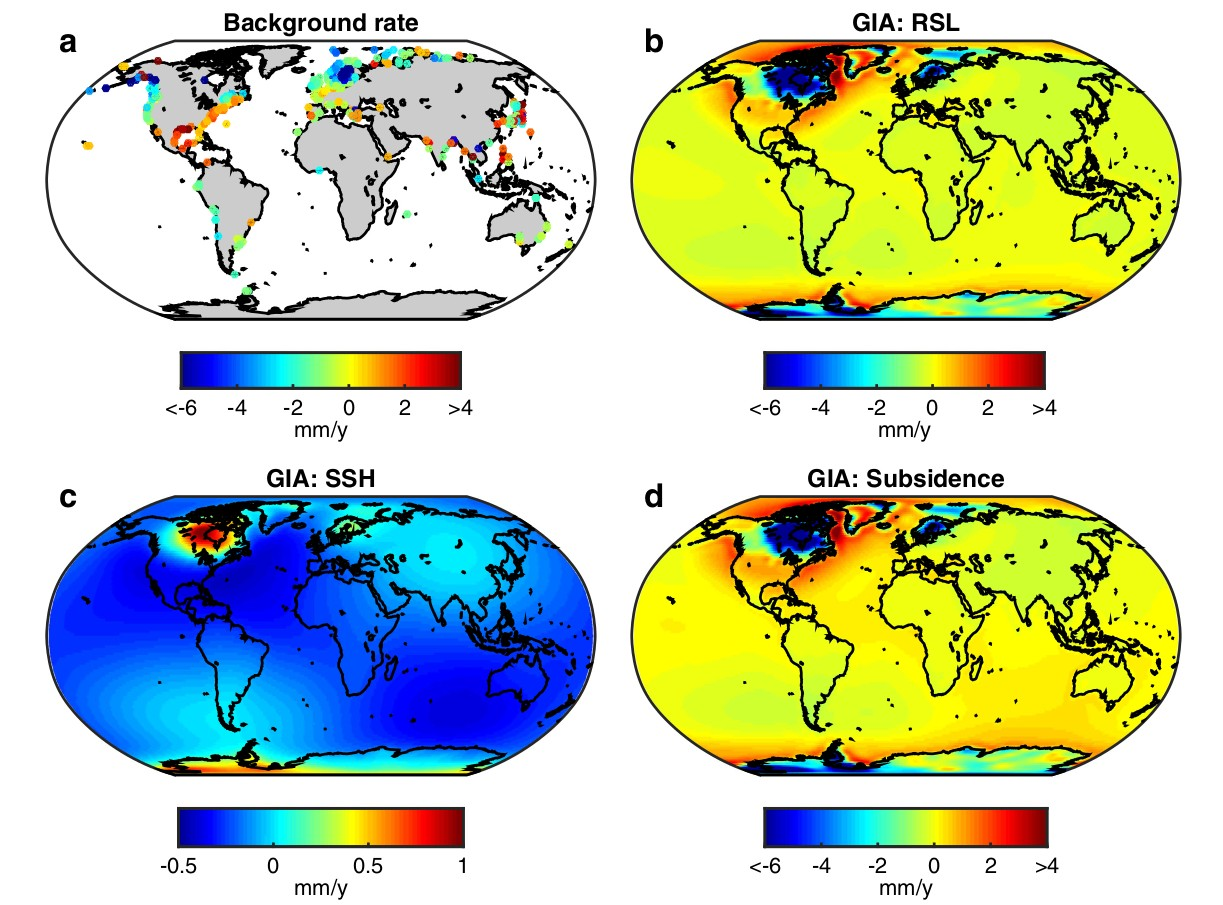<p style="font-size:90%;color:#444"><em>Present-day rates of relative sea level change from a GIA model (Kopp et al. 2015): (a) background rates at tide gauges, (b) the modelled GIA rate, (c) its geocentric part, (d) the vertical land motion.</em></p>

The readings in question 2 were corrected for GIA using a spherically symmetric viscosity model and an ice
reconstruction fitted to it. For each of the four gauges, say how large the correction is likely to be, whether its
sign is well known, and how confident you would be in it. Then explain in general why such corrections are uncertain,
and which of the six MWP1A sites in question 3 is most exposed to the same problem.

**Answer.** Stockholm sits near the centre of the former Fennoscandian ice sheet: relative sea level there is falling at about
8 to 9 mm yr$^{-1}$, several times the global rise. The sign and rough size are certain, since the uplift is
measured directly by GPS, but a few per cent error in a 9 mm yr$^{-1}$ correction is a large fraction of the 3 mm yr$^{-1}$
signal, and the models disagree at that level. Halifax lies on the collapsing peripheral bulge of the Laurentide ice
sheet, where GIA adds one to two millimetres per year of relative sea level rise; the sign is well established but the
magnitude varies between models by a large fraction of itself, because the bulge is where the predictions are most
sensitive to the viscosity profile and the ice margin. Honolulu and Simonstown are far-field sites where the GIA rate is
a few tenths of a millimetre per year, from the ocean-floor subsidence and continental levering; the corrections are
small and comparatively robust, though Hawaii sits on a hotspot with its own subsidence and a hot, weak mantle
beneath, so its background rate is not GIA alone.

The corrections are uncertain because the mantle certainly contains lateral viscosity variations of orders of
magnitude (question 3 of Practical 22) that the models neglect; any depth-dependent model that fits the palaeo data
does so with an ice history adjusted to compensate, so a good fit to the past is no guarantee of the present rate, and
the spread among models understates the true error because they share the same missing physics. Of the MWP1A sites
Scotland is the most exposed: its record contains a large local GIA signal from the British ice sheet that had to be
modelled and removed before fingerprinting, and Lin et al. found that most of their uncertainty at that site came
from the choice of ice model.

## 5. Altimetry, and a local projection  [paper; (b) optional]

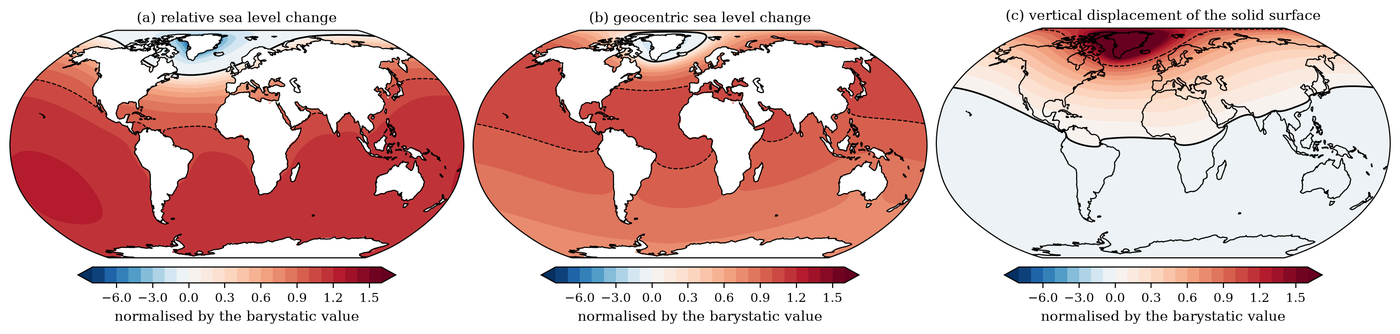<p style="font-size:90%;color:#444"><em>The Greenland fingerprint as (a) relative and (b) geocentric sea level change, and (c) their difference, the vertical motion of the sea floor, all normalised by the barystatic value.</em></p>

**(a)** Satellite altimetry gives a global mean rate of geocentric sea level rise of 3.4 mm yr$^{-1}$ over 1993 to 2023.
The ocean floor is sinking on average by about 0.3 mm yr$^{-1}$ because of GIA. The ocean average of the sea-floor
motion in the Greenland fingerprint is $-0.09$ of the barystatic value, and Greenland contributes about 0.6 mm yr$^{-1}$.
What is the corresponding rate of global mean (relative) sea level rise? State the sign of each correction and why.

**(b) Optional.** A regional projection is assembled as
$$ \Delta SL(\text{site}) = \Delta GMSL + \sum_j (a_j - 1)\,\Delta B_j + \Delta(\text{sterodynamic}) + \Delta u . $$
For 2100 under a middle emissions scenario the IPCC gives a global mean rise of about 0.56 m relative to 1995 to 2014,
made up of thermal expansion 0.20 m, glaciers 0.13 m, Greenland 0.08 m, Antarctica 0.11 m and land water 0.04 m. Take
the fingerprint coefficients for London to be those of Brest (Greenland 0.19, West Antarctica
1.10, East Antarctica 1.10) and for Sydney
(Greenland 0.99, West Antarctica 1.05, East Antarctica
0.89), split the Antarctic term equally between West and East, take the glacier
fingerprint to be about 0.9 at London and 1.1 at Sydney, ignore the sterodynamic term, and take vertical land motion of
$-1$ mm yr$^{-1}$ at London (bulge collapse plus subsidence of the Thames estuary) and zero at Sydney. Compare the two
local projections with the global mean.

**Answer.** **(a)** Geocentric and relative sea level differ by the vertical motion of the sea floor, $\Delta GSL = \Delta SL + \Delta u$.
The floor sinks under GIA ($\Delta u = -0.3$ mm yr$^{-1}$), so the relative rise exceeds the geocentric one by 0.3 mm
yr$^{-1}$. The elastic response to Greenland's melt also lowers the floor on average, by $0.09\times0.6 \approx 0.05$ mm
yr$^{-1}$, in the same sense. So $\Delta GMSL \approx 3.4 + 0.3 + 0.05 \approx 3.75$ mm yr$^{-1}$, before the sampling
correction for the polar gap. An altimeter always sees less rise than the ocean volume implies, and the standard GIA
correction of the altimetric product is of just this size.

**(b)** London: the departure from the mean is $(0.19-1)\times0.08 + (1.09-1)\times0.055 + (1.09-1)\times0.055 + (0.9-1)\times0.13
\approx -0.065 + 0.005 + 0.005 - 0.013 \approx -0.07$ m, and the land motion over 85 years adds $+0.085$ m of relative rise, giving
about $0.56 - 0.07 + 0.09 \approx 0.58$ m. Sydney: $(0.99-1)\times0.08 + (1.05-1)\times0.055 + (0.90-1)\times0.055 + (1.1-1)\times0.13
\approx 0.01$ m, so about 0.57 m. Both happen to be close to the global mean, but for different reasons: London loses almost
the whole Greenland term to the fingerprint and gains it back through subsidence, and the sterodynamic term, which was
ignored, can be of either sign and of order a decimetre at both places. The lesson is that the local number is
assembled from pieces with different physics and different uncertainties, and the largest of these, the Antarctic
term, is the least well known.